In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn

def rad(x, y):
    x = np.array(x)
    y = np.array(y)
    x /= np.linalg.norm(x)
    y /= np.linalg.norm(y)
    return np.arccos(np.clip(np.dot(x, y), -1.0, 1.0))

<Axes: xlabel='phn_start', ylabel='phn_start'>

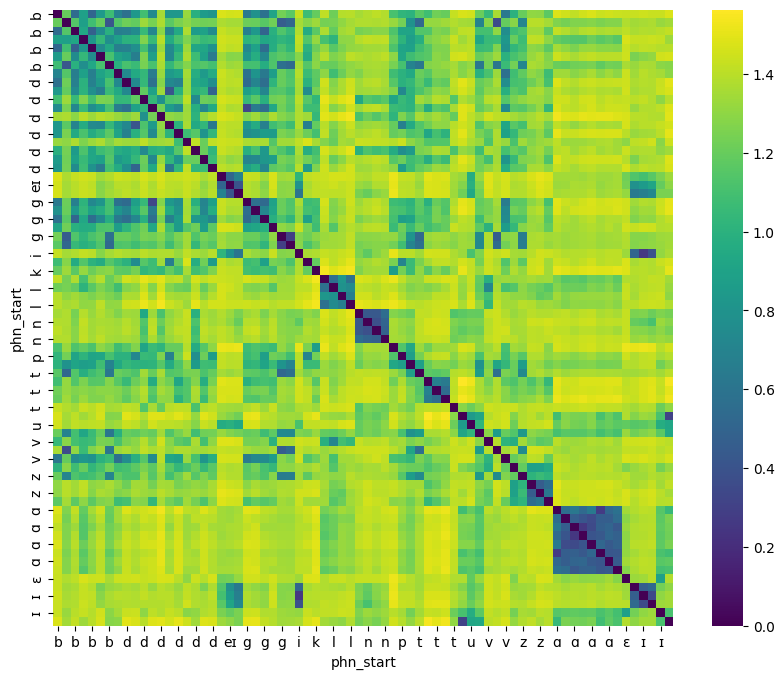

In [3]:
import seaborn

model = "hubert-large-en"
df = pd.read_pickle(f"data/sylber-{model}-24.pkl")
_df = df[df.step == 1][["phn_start", "feat"]].copy().sort_values("phn_start").reset_index()
n = len(_df)
sim_matrix = np.zeros((n, n))

# Compute similarity for all pairs
for i in range(n):
    for j in range(n):
        sim_matrix[i, j] = rad(_df['feat'][i], _df['feat'][j])
sim_df = pd.DataFrame(sim_matrix, index=_df['phn_start'], columns=_df['phn_start'])

# Plot heatmap
plt.figure(figsize=(10, 8))
seaborn.heatmap(sim_df, cmap="viridis")

In [4]:
dataset, model = "timit", "hubert-large-en"
layer = 24
df = pd.read_pickle(f"data/{dataset}-{model}-{layer}.pkl")

In [5]:
_df = df.groupby("phone", group_keys=False).sample(n=100, random_state=42)

In [6]:
phones = sorted(_df["phone"].unique())
avg_rad = pd.DataFrame(index=phones, columns=phones, dtype=float)
for p1 in tqdm(phones):
    f1s = _df[_df.phone == p1]["feat"].to_list()
    for p2 in phones:
        f2s = _df[_df.phone == p2]["feat"].to_list()
        avg_rad.loc[p1, p2] = np.mean([
            rad(f1, f2)
            for f1 in f1s
            for f2 in f2s
        ])

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 38/38 [05:00<00:00,  7.91s/it]


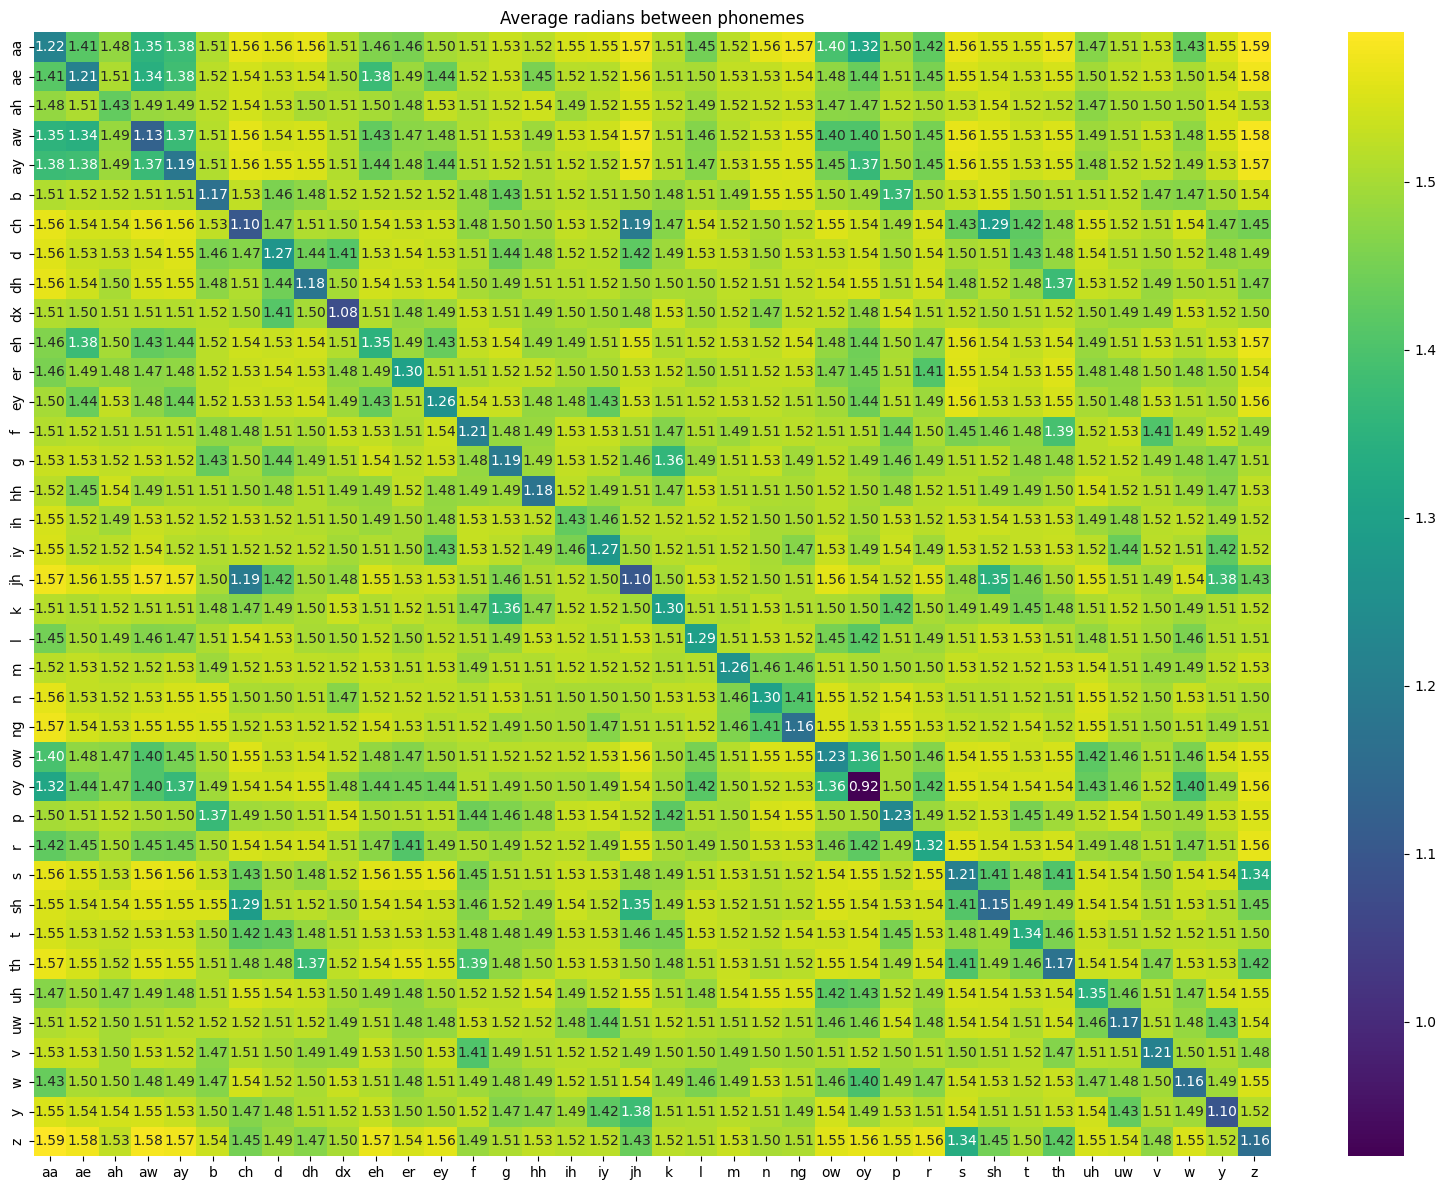

In [23]:
plt.figure(figsize=(16, 12))
seaborn.heatmap(avg_rad, annot=True, fmt=".2f", cmap="viridis")
plt.title("Average radians between phonemes")
plt.tight_layout()
plt.show()

Text(0, 0.5, 'SSL feature distance (Radians)')

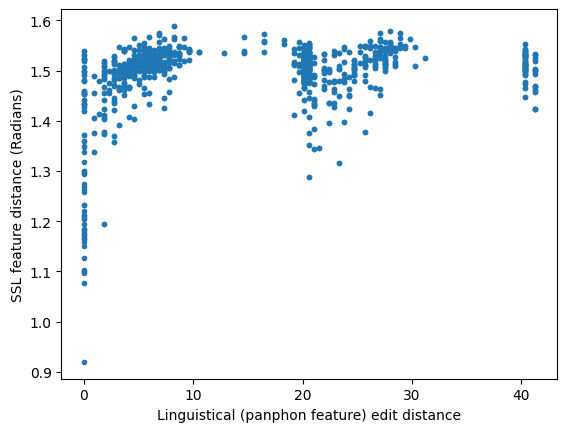

In [34]:
import panphon.distance

_arpabet2ipa = {'AA': 'ɑ', 'AE': 'æ', 'AH': 'ʌ', 'AH0': 'ə', 'AO': 'ɔ', 'AW': 'aʊ', 'AY': 'aɪ', 'EH': 'ɛ', 'ER': 'ɝ', 'ER0': 'ɚ', 'EY': 'eɪ', 'IH': 'ɪ', 'IH0': 'ɨ', 'IY': 'i', 'OW': 'oʊ', 'OY': 'ɔɪ', 'UH': 'ʊ', 'UW': 'u', 'B': 'b', 'CH': 'tʃ', 'D': 'd', 'DH': 'ð', 'EL': 'l̩ ', 'EM': 'm̩', 'EN': 'n̩', 'F': 'f', 'G': 'ɡ', 'HH': 'h', 'JH': 'dʒ', 'K': 'k', 'L': 'l', 'M': 'm', 'N': 'n', 'NG': 'ŋ', 'P': 'p', 'Q': 'ʔ', 'R': 'ɹ', 'S': 's', 'SH': 'ʃ', 'T': 't', 'TH': 'θ', 'V': 'v', 'W': 'w', 'WH': 'ʍ', 'Y': 'j', 'Z': 'z', 'ZH': 'ʒ'}
_arpabet2ipa.update({'AX': 'ə', 'AX-H': 'ə̥', 'AXR': 'ɚ', 'B': '', 'BCL': 'b', 'D': '', 'DCL': 'd', 'DX': 'ɾ', 'ENG': 'ŋ̍', 'EPI': '', 'G': '', 'GCL': 'g', 'HV': 'ɦ', 'H#': '', 'IX': 'ɨ', 'KCL': 'k', 'K': '', 'NX': 'ɾ̃', 'P': '', 'PAU': '', 'PCL': 'p', 'T': '', 'TCL': 't', 'UX': 'ʉ'})

pph = panphon.distance.Distance()
plt.plot(
    [
        pph.feature_edit_distance(_arpabet2ipa[p1.upper()], _arpabet2ipa[p2.upper()]) * 22
        for p1 in phones
        for p2 in phones
    ],
    [
        avg_rad.loc[p1, p2]
        for p1 in phones
        for p2 in phones
    ],
    ".",
)
plt.xlabel("Linguistical (panphon feature) edit distance")
plt.ylabel("SSL feature distance (Radians)")

In [37]:
for p1 in phones:
    for p2 in phones:
        if 1 <= (pph.feature_edit_distance(_arpabet2ipa[p1.upper()], _arpabet2ipa[p2.upper()]) * 22) <= 4:
            print(p1, p2)

aa ae
aa ah
aa eh
aa iy
ae aa
ae ah
ae eh
ae ih
ae iy
ae y
ah aa
ah ae
ah eh
ah hh
ah ih
ah iy
ah uh
ah uw
ah y
aw ay
aw ey
aw ow
ay aw
ay ey
ay ow
ay oy
ch jh
dh dx
dh l
dh n
dh s
dh sh
dh v
dh z
dx dh
dx l
dx n
dx r
dx z
eh aa
eh ae
eh ah
eh iy
eh uh
eh y
ey aw
ey ay
ey ow
ey oy
f s
f sh
f th
f z
hh ah
hh ng
hh y
ih ae
ih ah
ih uh
ih uw
ih y
iy aa
iy ae
iy ah
iy eh
iy uh
iy uw
iy y
jh ch
l dh
l dx
l n
l r
l s
l th
l z
m n
m ng
m v
n dh
n dx
n l
n m
n z
ng hh
ng m
ng y
ow aw
ow ay
ow ey
ow oy
oy ay
oy ey
oy ow
r dx
r l
r y
s dh
s f
s l
s sh
s th
s v
sh dh
sh f
sh s
sh th
sh z
th f
th l
th s
th sh
th z
uh ah
uh eh
uh ih
uh iy
uh uw
uh w
uh y
uw ah
uw ih
uw iy
uw uh
uw w
v dh
v m
v s
v z
w uh
w uw
w y
y ae
y ah
y eh
y hh
y ih
y iy
y ng
y r
y uh
y w
z dh
z dx
z f
z l
z n
z sh
z th
z v


In [41]:
pph.feature_edit_distance("b", "d") * 22

2.291666666666667